Source: Xavier Dupré

# Scikit-learn

Some simple exercises on *scikit-learn*. The notebook is long for those who are new to machine learning and probably suspense-free for those who have done it before.

In [3]:
%matplotlib inline

## Simple 2D Example

## What is Linear Regression?

Linear regression is one of the simplest and most fundamental machine learning algorithms. It models the relationship between a **dependent variable** $y$ (what we want to predict) and one or more **independent variables** $X$ (the features we use to make predictions).

### The Intuition

Imagine you have a scatter plot of points. Linear regression finds the **best straight line** that passes through (or near) those points.

- In **1D** (one feature): we fit a line $y = ax + b$
- In **2D** (two features): we fit a plane $y = a_1 x_1 + a_2 x_2 + b$
- In **nD** (n features): we fit a hyperplane

### The Mathematical Model

For a single feature $x$, the model is:

$$\hat{y} = \theta_0 + \theta_1 x$$

where:
- $\hat{y}$ is the **predicted** value
- $\theta_0$ is the **intercept** (bias) — where the line crosses the y-axis
- $\theta_1$ is the **slope** (weight) — how much $y$ changes when $x$ increases by 1

For multiple features, we write it in matrix form:

$$\hat{y} = X \cdot \theta$$

where:
- $X$ is the matrix of features (with a column of 1s for the intercept)
- $\theta$ is the vector of parameters $[\theta_0, \theta_1, ..., \theta_p]$

### What does "best line" mean?

We need a way to measure how **good** or **bad** our line is. We use a **cost function** (also called loss function) that measures the error between our predictions $\hat{y}$ and the true values $y$.

The most common cost function for linear regression is the **Mean Squared Error (MSE)**:

$$J(\theta) = \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

This computes the average of the squared differences between predictions and actual values. We square the errors so that:
1. Positive and negative errors don't cancel out
2. Large errors are penalized more heavily

**Our goal**: find the values of $\theta$ that **minimize** this cost function.


### Two Ways to Find the Best Parameters

There are two main approaches to find the optimal $\theta$:

---

#### Method 1: The Normal Equation (Analytical Solution)

There is a **closed-form** formula that directly computes the optimal parameters:

$$\theta^* = (X^T X)^{-1} X^T y$$

**Pros**: Exact solution, no hyperparameters to tune  
**Cons**: Computationally expensive for large datasets (matrix inversion is $O(n^3)$)

---

#### Method 2: Gradient Descent (Iterative Optimization)

Instead of computing the solution directly, we **iteratively improve** our parameters by taking small steps in the direction that reduces the cost function.

The idea is simple:
1. Start with random parameters $\theta$
2. Compute the gradient (slope) of the cost function — this tells us in which direction the cost increases
3. Move $\theta$ in the **opposite** direction (to decrease the cost)
4. Repeat until convergence

The update rule is:

$$\theta := \theta - \alpha \cdot \nabla J(\theta)$$

where $\alpha$ is the **learning rate** (how big each step is).

**Pros**: Works for very large datasets, generalizes to other problems  
**Cons**: Requires choosing a learning rate, may not converge if poorly tuned

---

### Evaluating the Model: $R^2$ Score

Once we have our model, we need to evaluate how well it fits the data. The **coefficient of determination** $R^2$ measures how much of the variance in $y$ is explained by the model:

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

- $R^2 = 1$: perfect fit (predictions = actual values)
- $R^2 = 0$: model predicts no better than the mean
- $R^2 < 0$: model is worse than just predicting the mean


## 1. Synthetic data

**1. Simulate a random data set of size $(n, 1)$ with ``make_regression``.**.



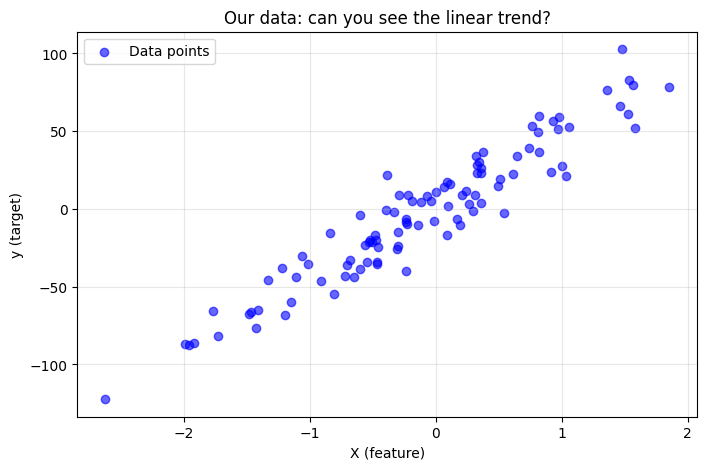

X shape: (100, 1)  -> 100 samples, 1 feature
y shape: (100,)  -> 100 target values


In [14]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic data: 100 samples, 1 feature, with some noise
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
plt.xlabel('X (feature)')
plt.ylabel('y (target)')
plt.title('Our data: can you see the linear trend?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"X shape: {X.shape}  -> {X.shape[0]} samples, {X.shape[1]} feature")
print(f"y shape: {y.shape}  -> {y.shape[0]} target values")

### Exercise: Implement Linear Regression with the Normal Equation

Before using gradient descent, let's first solve the problem **analytically** using the Normal Equation:

$$\theta^* = (X^T X)^{-1} X^T y$$

**Steps to implement:**
1. Add a column of 1s to $X$ (for the intercept term $\theta_0$)
2. Apply the formula above
3. Extract the intercept and slope from $\theta^*$

**Hint**: Use `np.hstack` or `np.column_stack` to add the bias column, and `np.linalg.inv` for matrix inversion.

In [17]:
print(X[:5])
X_b = np.column_stack([np.ones(X.shape[0]), X])
print(X_b[:5])

[[ 0.93128012]
 [ 0.08704707]
 [-1.05771093]
 [ 0.31424733]
 [-0.47917424]]
[[ 1.          0.93128012]
 [ 1.          0.08704707]
 [ 1.         -1.05771093]
 [ 1.          0.31424733]
 [ 1.         -0.47917424]]


In [31]:
# theta = (X^T X)^{-1} X^T y
np.matmul(X_b.T, X_b) == X_b.T @ X_b

np.matmul(np.matmul(np.linalg.inv(np.matmul(X_b.T, X_b)), X_b.T), y)

array([ 1.74767298, 45.78520483])

In [ ]:
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y  
theta_0, theta_1 = theta_best
print(f"theta_0 (intercept): {theta_0:.2f}")
print(f"theta_1 (slope): {theta_1:.2f}")

theta_0 (intercept): 1.75
theta_1 (slope): 45.79


Intercept (theta_0): 1.7477
Slope (theta_1): 45.7852


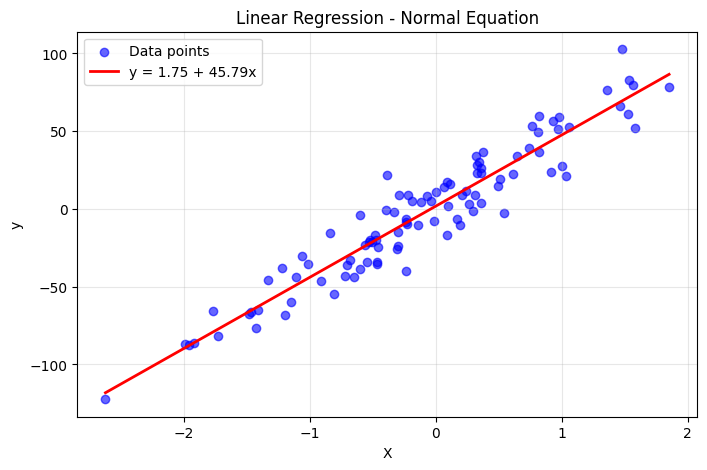


R² score: 0.9069


In [32]:
# EXERCISE: Implement the Normal Equation

# Step 1: Add a column of 1s to X for the intercept (bias) term
# X_b should have shape (n_samples, 2): [1, x] for each sample
X_b = np.column_stack([np.ones(X.shape[0]), X])

# Step 2: Apply the Normal Equation: theta = (X^T X)^{-1} X^T y
# TODO: Implement this (replace None with the formula)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y  # <-- YOUR CODE HERE

# Step 3: Extract intercept and slope
# theta_best[0] = intercept (theta_0)
# theta_best[1] = slope (theta_1)
print(f"Intercept (theta_0): {theta_best[0]:.4f}")
print(f"Slope (theta_1): {theta_best[1]:.4f}")

# Step 4: Plot the regression line on top of the data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = theta_best[0] + theta_best[1] * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'y = {theta_best[0]:.2f} + {theta_best[1]:.2f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression - Normal Equation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 5: Calculate R² score manually
y_pred = X_b @ theta_best
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"\nR² score: {r2:.4f}")

### Exercise: Implement Linear Regression with Gradient Descent

Now let's solve the same problem **iteratively** using Gradient Descent. This is the approach used in practice for large datasets and is the foundation of deep learning.

**Reminder of the algorithm:**

1. Initialize $\theta$ randomly
2. Repeat for `epochs` iterations:
   - Compute predictions: $\hat{y} = X \cdot \theta$
   - Compute the gradient: $\nabla J(\theta) = \frac{2}{n} X^T (\hat{y} - y)$
   - Update parameters: $\theta := \theta - \alpha \cdot \nabla J(\theta)$

**Why does this work?** The gradient tells us the direction of steepest **increase** of the cost. By moving in the **opposite** direction (subtracting), we reduce the cost at each step.

$$\beta = (X^tX)^{-1} X^t y$$

* Build a ```cost``` function for the linear regression
* Build a ```predict``` function using the features and the coefficient of the model
* Build a ```fit``` function with a gradient descent algorithm to minimize the cost function over the training dataset. 

## Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the cost function in machine learning and deep learning models. It is an iterative algorithm that starts with an initial set of parameters and updates them to minimize the cost function.

### Steps of Gradient Descent:

1. **Initialize Parameters**: Start with initial values for the parameters (weights and biases).

2. **Compute the Cost Function**: Calculate the cost function, which measures how well the model's predictions match the actual data.

3. **Compute the Gradient**: Calculate the gradient of the cost function with respect to each parameter. The gradient is a vector of partial derivatives that points in the direction of the steepest increase in the cost function.

4. **Update Parameters**: Update the parameters by moving them in the opposite direction of the gradient. The size of the step is determined by the learning rate.

    $$
    \theta = \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}
    $$

    where:
    - $\theta$ is the parameter vector (randomly initialized).
    - $\alpha$ is the learning rate.
    - $\frac{\partial J(\theta)}{\partial \theta}$ is the gradient of the cost function (in our case it is the gradient of the Mean Squared Error).

5. **Repeat**: Repeat steps 2-4 until the cost function converges to a minimum or a predefined number of iterations is reached.

### Types of Gradient Descent:

1. **Batch Gradient Descent**: Uses the entire dataset to compute the gradient at each step. It can be slow for large datasets.

2. **Stochastic Gradient Descent (SGD)**: Uses one training example to compute the gradient at each step. It is faster but can have high variance in the updates.

3. **Mini-Batch Gradient Descent**: Uses a small batch of training examples to compute the gradient at each step. It balances the speed of SGD and the stability of Batch Gradient Descent.

### Advantages:

- Simple to implement.
- Efficient for large datasets.
- Can be used for various types of machine learning models.

### Disadvantages:

- Requires careful tuning of the learning rate.
- Can get stuck in local minima.
- May require many iterations to converge.

Gradient Descent is a fundamental algorithm in machine learning and is widely used for training models, especially in deep learning.

In [53]:
import numpy as np

# Cost function: Mean Squared Error
# Measures how far our predictions are from the true values
def MSE(y_pred, y):
    """
    Compute Mean Squared Error.
    
    Parameters:
        y_pred: predicted values (n,)
        y: true values (n,)
    
    Returns:
        float: mean of squared differences
    
    Formula: MSE = (1/n) * sum((y_pred - y)^2)
    """

    # Point de vigilance sur le np.mean:
    # Par defaut, l'opérateur applique la moyenne à TOUT l'array,
    # Si vous souhaitez effectuer la moyenne par ligne ou par colonne, il faut spécifier l'argument axis (0 pour les colonnes, 1 pour les lignes).
    return np.mean((y_pred-y)**2)

# Gradient of the MSE with respect to theta
def gradient(X, y, theta):
    """
    Compute the gradient of MSE with respect to theta.
    
    Parameters:
        X: feature matrix with bias column (n, p+1)
        y: true values (n,)
        theta: current parameters (p+1,)
    
    Returns:
        gradient vector (p+1,)
    
    Formula: gradient = (2/n) * X^T @ (X @ theta - y)
    """
    n = len(y)
    y_pred = predict(X, theta)
    return 2 * X.T @ (y_pred - y) /n

# Prediction function
def predict(X, theta):
    """
    Compute predictions: y_hat = X @ theta
    
    Parameters:
        X: feature matrix with bias column (n, p+1)
        theta: parameters (p+1,)
    
    Returns:
        predictions (n,)
    """
    return X @ theta

# Gradient descent optimization
def fit(X, y, lr=0.01, epochs=1000):
    """
    Find optimal theta using gradient descent.
    
    Parameters:
        X: feature matrix WITHOUT bias column (n, p)
        y: true values (n,)
        lr: learning rate (alpha) - how big each step is
        epochs: number of iterations
    
    Returns:
        theta: optimized parameters (p+1,)
    """
    # Add bias column (column of 1s)
    X_b = np.column_stack([np.ones(X.shape[0]), X])
    
    # Initialize theta randomly
    theta = np.random.randn(X_b.shape[1])
    
    # Store cost history to visualize convergence
    cost_history = []
    
    for i in range(epochs):
        # TODO: 1. Compute gradient
        grad = gradient(X_b, y, theta)
        # TODO: 2. Update theta
        theta = theta - lr*grad
        # TODO: 3. (Optional) Store MSE for visualization
        cost_history.append(MSE(predict(X_b, theta), y))
    
    return theta, cost_history

# Fit the model
theta, cost_history = fit(X, y, lr=0.01, epochs=400)
print(f"Theta found by gradient descent: {theta}")
print(f"Compare with Normal Equation:    {theta_best}")

# Compute the R² score for the gradient descent solution AND for the closed form solution
y_pred_gd = predict(np.column_stack([np.ones(X.shape[0]), X]), theta)
ss_res_gd = np.sum((y - y_pred_gd) ** 2)
ss_tot_gd = np.sum((y - np.mean(y)) ** 2)
r2_gd = 1 - ss_res_gd / ss_tot_gd
print(f"R² score for Gradient Descent: {r2_gd:.4f}")

y_pred_ne = predict(X_b, theta_best)
ss_res_ne = np.sum((y - y_pred_ne) ** 2)
ss_tot_ne = np.sum((y - np.mean(y)) ** 2)
r2_ne = 1 - ss_res_ne / ss_tot_ne
print(f"R² score for Normal Equation:   {r2_ne:.4f}")


Theta found by gradient descent: [ 1.71830584 45.71355035]
Compare with Normal Equation:    [ 1.74767298 45.78520483]
R² score for Gradient Descent: 0.9069
R² score for Normal Equation:   0.9069


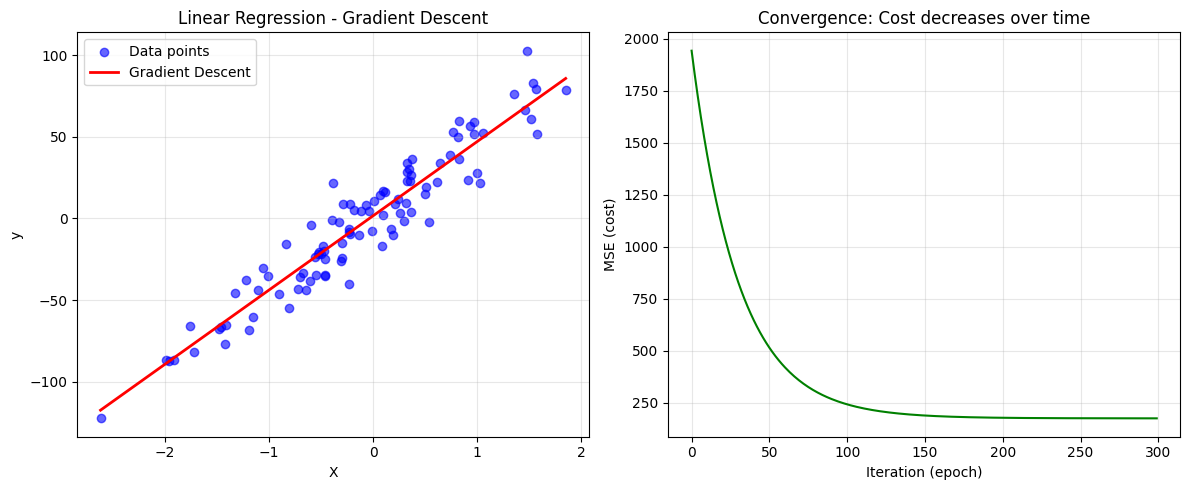

In [45]:
# Plot the regression line from gradient descent
plt.figure(figsize=(12, 5))

# Left plot: the regression line
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = theta[0] + theta[1] * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Gradient Descent')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression - Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)

# Right plot: cost function over iterations (convergence)
plt.subplot(1, 2, 2)
plt.plot(cost_history, color='green')
plt.xlabel('Iteration (epoch)')
plt.ylabel('MSE (cost)')
plt.title('Convergence: Cost decreases over time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise: Experiment with the Learning Rate

The **learning rate** $\alpha$ is crucial:
- **Too small**: convergence is very slow (needs many iterations)
- **Too large**: the cost may oscillate or even diverge (the model "overshoots")
- **Just right**: smooth, fast convergence

**Try different learning rates** (e.g., 0.001, 0.01, 0.1, 1.0) and observe how the convergence plot changes.

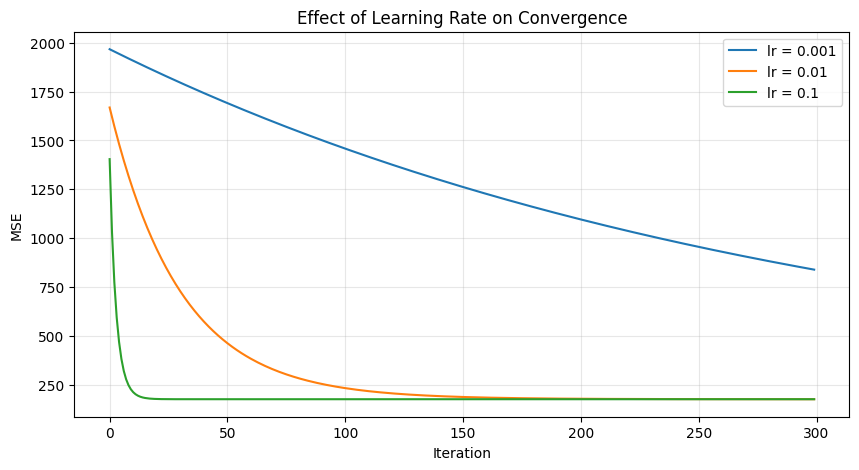

In [59]:
# EXERCISE: Compare different learning rates
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10, 5))
for lr in learning_rates:
    _, history = fit(X, y, lr=lr, epochs=300)
    plt.plot(history, label=f'lr = {lr}')

plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO: What happens if you set lr=1.0? Try it and explain what you observe.

### Exercise: Use Scikit-learn's LinearRegression

Now that you understand how linear regression works under the hood, let's use **scikit-learn** which provides a clean, optimized implementation.

The workflow in scikit-learn always follows the same pattern:
1. **Import** the model class
2. **Instantiate** the model: `model = LinearRegression()`
3. **Fit** (train) the model: `model.fit(X_train, y_train)`
4. **Predict**: `y_pred = model.predict(X_test)`
5. **Evaluate**: compute a score (e.g., $R^2$)

**Implement this below and compare the results with your manual implementation.**

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Create the model
model = LinearRegression()

# Step 2: Fit the model on our data
# TODO: model.fit(?, ?)
model.fit(X, y)

# Step 3: Get the learned parameters
print(f"Sklearn intercept: {model.intercept_:.4f}")
print(f"Sklearn slope: {model.coef_[0]:.4f}")

# Step 4: Compare with our implementations
print(f"\nNormal Equation: intercept={theta_best[0]:.4f}, slope={theta_best[1]:.4f}")
print(f"Gradient Descent: intercept={theta[0]:.4f}, slope={theta[1]:.4f}")

# Step 5: Compute R² score
y_pred_sklearn = model.predict(X)
print(f"\nR² score (sklearn): {r2_score(y, y_pred_sklearn):.4f}")

Sklearn intercept: 1.7477
Sklearn slope: 45.7852

Normal Equation: intercept=1.7477, slope=45.7852
Gradient Descent: intercept=1.7183, slope=45.7136

R² score (sklearn): 0.9069


# Multi dimensional data

## 1. Synthetic data

**1. Simulate a random data set of size $(n, 2)$ with ``numpy.random``.**.

**2. Store the sample in a variable $X$.**.
    

Subsequently, consider $X = (X_1, X_2)$.



In [93]:
import numpy as np

n = 1000
X=np.random.rand(n, 2)
X

array([[0.82428892, 0.91364982],
       [0.96620935, 0.96372457],
       [0.18182825, 0.4261254 ],
       ...,
       [0.24116238, 0.08236071],
       [0.43612796, 0.55746247],
       [0.81216311, 0.36185556]], shape=(1000, 2))

From $X$, calculate $$Y = 3 X_1-2X_2^2 + \epsilon$$ 
with $\epsilon \in [0,1]$

In [141]:
y = 3 * X[:, 0] - 2 * X[:, 1]**2 + np.random.randn(n)*0.1 + 4*X[:, 0]*X[:, 1]
y[:5]

array([3.80786361, 4.72073264, 0.63017481, 3.56467382, 2.11439405])

## 2. Train, validation, test

When training a model, it is customary to divide the training data set into 2 parts:

- A training part (*train set*), to calibrate the model
- A validation part (*validation set*), to evaluate the model during training.

To test the generalizability of the model, once training on the training set is complete, the model is **only** evaluated on (we NEVER use the test set during training):
- An evaluation set (*test set*)


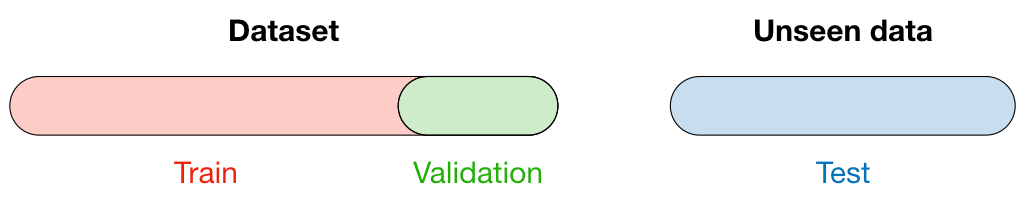

**Perform this distribution in the training set with variables $X_{train}, Y_{train}$ (X_train, Y_train) and in the validation set $X_{test}, Y_{test}$ (X_test, Y_test) with an 80/20 distribution (train/test).**

In [142]:
# Without sklearn

n_train = int(0.8 * n)
X_train = X[:n_train]
X_test = X[n_train : ]

y_train = y[:n_train]
y_test = y[n_train : ]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(800, 2) (200, 2) (800,) (200,)


In [143]:
# With sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True ) # Shuffle = False si on ne veut pas mélanger les données avant le split



**Visualise the data in 3D**

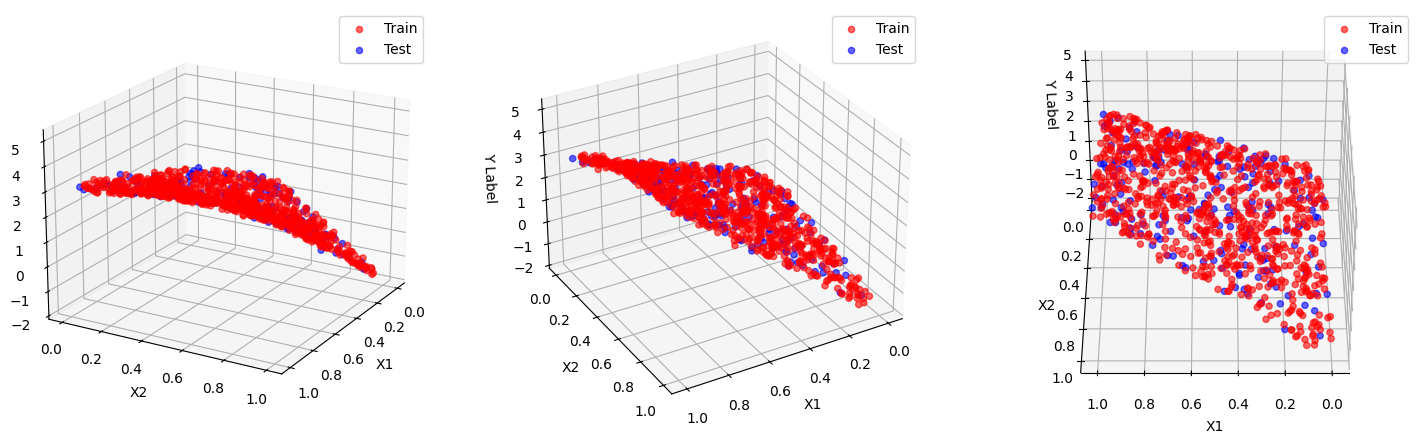

In [145]:
# 3D Plot of data with train and test labels
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 6))

# First view
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_train[:,0], X_train[:, 1], y_train, color='red', alpha=0.6, label='Data points')
ax1.scatter(X_test[:,0], X_test[:, 1], y_test, color='blue', alpha=0.6, label='Test points')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Y Label')
ax1.legend(['Train', 'Test'])
ax1.grid(True, alpha=0.3)
ax1.view_init(elev=20, azim=30)  # Change elevation and azimuth

# Second view
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_train[:,0], X_train[:, 1], y_train, color='red', alpha=0.6, label='Data points')
ax2.scatter(X_test[:,0], X_test[:, 1], y_test, color='blue', alpha=0.6, label='Test points')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('Y Label')
ax2.legend(['Train', 'Test'])
ax2.grid(True, alpha=0.3)
ax2.view_init(elev=30, azim=60)  # Change elevation and azimuth

# Third view
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_train[:,0], X_train[:, 1], y_train, color='red', alpha=0.6, label='Data points')
ax3.scatter(X_test[:,0], X_test[:, 1], y_test, color='blue', alpha=0.6, label='Test points')
ax3.set_xlabel('X1')
ax3.set_ylabel('X2')
ax3.set_zlabel('Y Label')
ax3.legend(['Train', 'Test'])
ax3.grid(True, alpha=0.3)
ax3.view_init(elev=40, azim=90)  # Change elevation and azimuth

plt.show()

## 3. Linear Regression

**On the previously generated data, calibrate a linear regression with sklearn and calculate the coefficient $R^2$.**

$$\beta = (X^tX)^{-1} X^t y$$  
    


* Calibrate a linear regression using previously computed functions in numpy

In [146]:
theta, mse_list = fit(X_train, y_train, lr=0.1, epochs=10000)
print(theta)

[-0.7151198   5.0416213   0.05074936]


* Calibrate a linear regression using sklearn

In [147]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[5.04,0.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.7151
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[8.16,8.08]"


* Display the model's coefficients

In [148]:
print(f"Sklearn intercept: {LR.intercept_:.4f}")
print(f"Sklearn coeff: {LR.coef_}") 

Sklearn intercept: -0.7151
Sklearn coeff: [5.0416213  0.05074936]


* Calculate the $R^2$

In [149]:
from sklearn.metrics import r2_score
print("R^2 score:", LR.score(X_test,y_test))
print(r2_score(y_test, LR.predict(X_test)))

R^2 score: 0.942426123588483
0.942426123588483


**What can you say about the choice of model (**Linear Regression**) given the complexity of the data ($Y = 3 X_1 - 2 X_2^2 + \epsilon$)?**

## 4. Polynomial Features

→*The linear model does not capture the non-linear effects ($X_2^2$) present in the explanatory variables.
In this case, we need to perform a transformation $$Z = X_2^2$$ and model $$Y = 3 X_1 - 2 Z + \epsilon$$*

*This response variable is linear and can be modeled by Linear Regression.

*The function [``PolynomialFeatures``](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) can be used to perform this transformation $Z = X_2^2$.


**Use ``PolynomialFeatures`` to perform this transformation.**
    


In [152]:
X_train_manual = np.column_stack([X_train[:, 0], X_train[:, 1]**2, X_train[:, 0]*X_train[:, 1]])
LR_manual = LinearRegression()
LR_manual.fit(X_train_manual, y_train)

print("Coefficients:", LR_manual.coef_)
print("Intercept:", LR_manual.intercept_)
# print("R^2 score:", LR_manual.score(X_train_manual, y_train))
print("R^2 score on test set:", LR_manual.score(np.column_stack([X_test[:, 0], X_test[:, 1]**2, X_test[:, 0]*X_test[:, 1]]), y_test))
print(r2_score(y_test, LR_manual.predict(np.column_stack([X_test[:, 0], X_test[:, 1]**2, X_test[:, 0]*X_test[:, 1]]))))

Coefficients: [ 3.02504284 -1.96381442  3.94672418]
Intercept: -0.014620674813359713
R^2 score on test set: 0.9950971581869196
0.9950971581869196


In [165]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.transform(X_test)

LR_poly = LinearRegression()
LR_poly.fit(X_train2, y_train)
print("Polynomial Regression Coefficients:", LR_poly.coef_)
print("Polynomial Regression Intercept:", LR_poly.intercept_)
print("Polynomial Regression R^2 score on test set:", LR_poly.score(X_test2, y_test))
print(r2_score(y_test, LR_poly.predict(X_test2)))

Polynomial Regression Coefficients: [ 2.99454945 -0.08218313  0.01782271  3.97130843 -1.89823855]
Polynomial Regression Intercept: 0.007806658723515936
Polynomial Regression R^2 score on test set: 0.9951384521822386
0.9951384521822386


In [ ]:
# Now with the sklearn pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('lr', LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Coefficients:", pipeline.named_steps['lr'].coef_)
print("Intercept:", pipeline.named_steps['lr'].intercept_)
print("R^2 score:", pipeline.score(X_train, y_train))
print("R^2 score on test set:", pipeline.score(X_test, y_test))


Coefficients: [ 0.          2.99454945 -0.08218313  0.01782271  3.97130843 -1.89823855]
Intercept: 0.007806658723521709
R^2 score: 0.9955031654467043
R^2 score on test set: 0.9951384521822386



**Calibrate a linear regression on the new data.**


In [ ]:
# [...]

LinearRegression(fit_intercept=False)


**Calculate the $R^2$ and compare it to the previous model.**
    


In [ ]:
# [...]

0.9349708314296543

## 5. Random forest

**Calibrate a random forest on previously generated data.**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# [...]


RandomForestRegressor()

**Give the model's $R^2$ coefficient.**
    

In [ ]:
# [...]

0.9023196315317898

The linear model is the best model in our case, since the data have been constructed in this way. It is expected that the $R^2$ will not be (significantly) higher.

**Calibrate the model on polynomial features.**

In [ ]:
# [...]

0.9017468159435128

## 6. With new data

**Compare the two models on the following data. What do you notice? Explain why?**

In [108]:
X_test2 = random.rand(n, 2) + 0.5
y_test2 = X_test2[:, 0] * 3 - 2 * X_test2[:, 1] ** 2 + random.rand(n)

In [ ]:
# [...]


,name,r2,r2_jeu2
0,LinearRegression,0.913263,0.716481
1,LinearRegression + X^2,0.934971,0.959069
2,RandomForestRegressor,0.902320,0.578328
3,RandomForestRegressor + X^2,0.901747,0.571136


[...]


## 7. Plots

**Plot $Y$ for a fixed $X_2$, then $Y$ for a fixed $X_1$**.

In [11]:
import matplotlib.pyplot as plt
# [...]


**For each model, plot the predictions on the X_test2 set and add a legend with the name of each model used**.

In [12]:
# [...]


The graph studies the model variables according to one coordinate, while restricting the other to a given interval. We can see immediately that the random forest becomes constant beyond a certain threshold. Once again, this is quite normal, since the learning base only contains $X_1, X_2$ in the interval $[0, 1]$. Apart from that, each decision tree produces a constant value, simply because they are staircase functions: a random forest is an average of staircase functions, and is therefore bounded. As for the first linear regression, it cannot capture second-degree effects; it is linear with respect to the initial variables. It deviates less, but still deviates from the variable to be predicted.

The aim of this exercise is to illustrate that a machine learning model is estimated on a dataset that follows a certain distribution. When the data on which the model is used to predict no longer follows this distribution, the models return answers that are likely to be wrong, in different ways depending on the model.

This is why we say that machine learning models need to be relearned regularly, especially if they are applied to data generated by human activity and not data derived from physical problems.

## 7. Overfitting

**Illustrate overlearning on the ``X_train`` dataset by varying the depth of a decision tree**.


In [13]:
from sklearn.tree import DecisionTreeRegressor

# [...]


In [14]:
# [...]

## 8. Feature number increase

### Lasso and Ridge Regression Regularization

**Lasso Regression (L1 Regularization):**

Lasso regression adds a penalty equal to the absolute value of the magnitude of coefficients to the loss function. This type of regularization can shrink some coefficients to zero, effectively performing feature selection. The loss function for Lasso regression is:

$$
L(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$

where:
- $ y_i $ is the actual value.
- $ \hat{y}_i $ is the predicted value.
- $ \beta_j $ are the coefficients.
- $ \lambda $ is the regularization parameter that controls the strength of the penalty.

**Ridge Regression (L2 Regularization):**

Ridge regression adds a penalty equal to the square of the magnitude of coefficients to the loss function. This type of regularization can shrink coefficients but does not set them to zero. The loss function for Ridge regression is:

$$
L(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2
$$

where:
- $ y_i $ is the actual value.
- $ \hat{y}_i $ is the predicted value.
- $ \beta_j $ are the coefficients.
- $ \lambda $ is the regularization parameter that controls the strength of the penalty.

**Comparison:**

- **Lasso Regression** can be used for feature selection as it can shrink some coefficients to zero.
- **Ridge Regression** is useful when you have multicollinearity in your data as it can shrink coefficients but does not eliminate any features.
- Both methods help to prevent overfitting by adding a penalty to the loss function, which discourages large coefficients.

**Choosing between Lasso and Ridge:**

- Use **Lasso** when you want to perform feature selection and have a sparse model.
- Use **Ridge** when you want to keep all features but reduce the impact of less important ones.

**Elastic Net:**

Elastic Net is a combination of both Lasso and Ridge regression. It adds both L1 and L2 penalties to the loss function:

$$
L(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2
$$

This method can be useful when you have many correlated features.

**Observe the impact of regularizing the coefficients of a logistic regression as the number of features increases**.
    

In [15]:
from sklearn.linear_model import Ridge, Lasso
import numpy.linalg as nplin
import numpy

# [...]

In [17]:
# [...]